# Pharmaceutical HCP Segmentation & Commercial Analytics

## Notebook 03 – Exploratory Data Analysis (EDA)

### Objective

This notebook explores the cleaned pharmaceutical datasets to identify prescribing trends, HCP characteristics, regional patterns, product performance, and survey insights.

The analysis focuses on generating business insights that can support commercial strategy and HCP targeting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

plt.rcParams["figure.figsize"] = (10,6)

In [2]:
hcp = pd.read_csv("../data/cleaned/hcp_master_cleaned.csv")

products = pd.read_csv("../data/cleaned/products_cleaned.csv")

prescriptions = pd.read_csv("../data/cleaned/prescriptions_cleaned.csv")

survey = pd.read_csv("../data/cleaned/survey_cleaned.csv")

In [3]:
eda = prescriptions.merge(
    hcp,
    on="HCP_ID",
    how="left"
)

eda = eda.merge(
    products,
    on=["Product_ID","Product_Name","Therapy_Area"],
    how="left"
)

eda.head()

,Prescription_ID,HCP_ID,Product_ID,Product_Name,Therapy_Area,Month,Year,TRx,NRx,Sales_Calls,...,Specialty,Hospital_Type,Practice_Type,Patient_Volume,Region,State,City,Tier,Launch_Year,Unit_Price_INR
0,RX000001,HCP00107,P002,HeartPlus,Cardiovascular,March,2025,248.0,12,10,...,Cardiology,Medical College,Solo Practice,High,North,Uttar Pradesh,Lucknow,Tier 1,2021,920.0
1,RX000002,HCP02245,P003,VasoCare,Cardiovascular,September,2025,99.0,76,11,...,Cardiology,Clinic,Group Practice,Medium,East,Bihar,Patna,Tier 2,2023,1100.0
2,RX000003,HCP00986,P006,DiaControl,Diabetes,June,2025,103.0,90,10,...,Endocrinology,Government,Group Practice,Medium,North,Punjab,Amritsar,Tier 2,2024,980.0
3,RX000004,HCP02118,P012,ChemoCare,Oncology,November,2025,250.0,248,8,...,Oncology,Private,Solo Practice,High,North,Punjab,Ludhiana,Tier 2,2023,3100.0
4,RX000005,HCP00113,P002,HeartPlus,Cardiovascular,January,2026,234.0,214,4,...,Cardiology,Private,Group Practice,High,North,Uttar Pradesh,Noida,Tier 1,2021,920.0


In [4]:
eda.shape

(100000, 26)

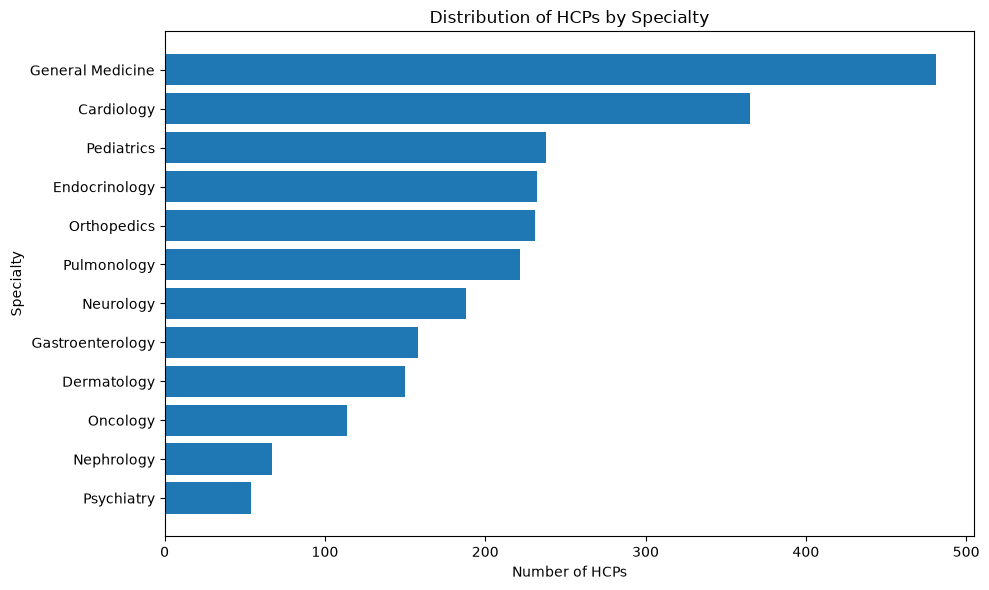

In [5]:
specialty = (
    hcp["Specialty"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10,6))

plt.barh(
    specialty.index,
    specialty.values
)

plt.title("Distribution of HCPs by Specialty")

plt.xlabel("Number of HCPs")

plt.ylabel("Specialty")

plt.tight_layout()

plt.show()

## HCP Distribution by Region

This visualization shows how healthcare professionals are distributed across different geographical regions.

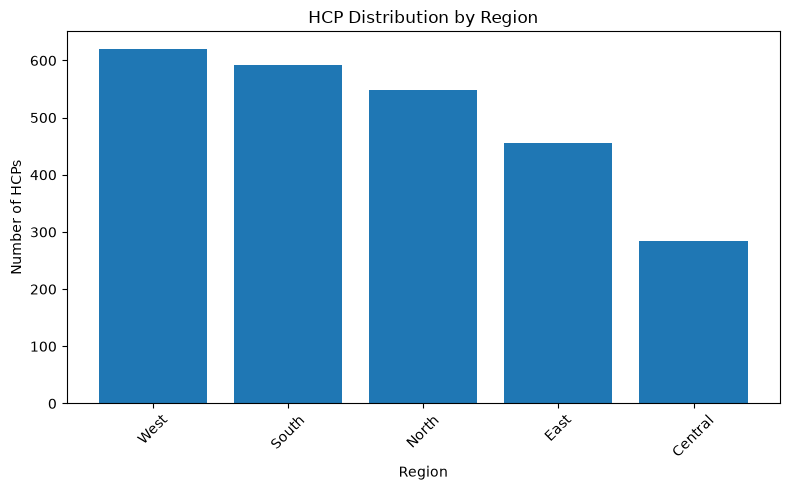

In [6]:
region = (
    hcp["Region"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(
    region.index,
    region.values
)

plt.title("HCP Distribution by Region")

plt.xlabel("Region")

plt.ylabel("Number of HCPs")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## HCP Distribution by Hospital Type

This chart illustrates the distribution of HCPs across different hospital types.

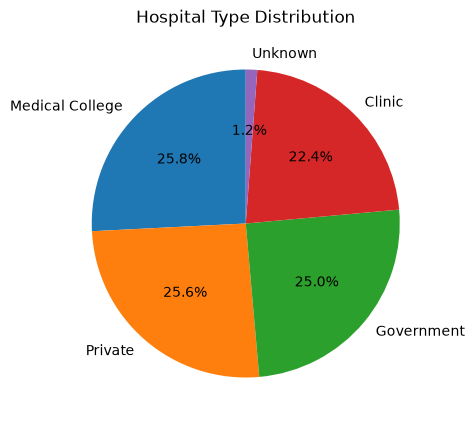

In [7]:
hospital = (
    hcp["Hospital_Type"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.pie(
    hospital.values,
    labels=hospital.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Hospital Type Distribution")

plt.show()

## Age Distribution of HCPs

This histogram displays the age distribution of healthcare professionals.

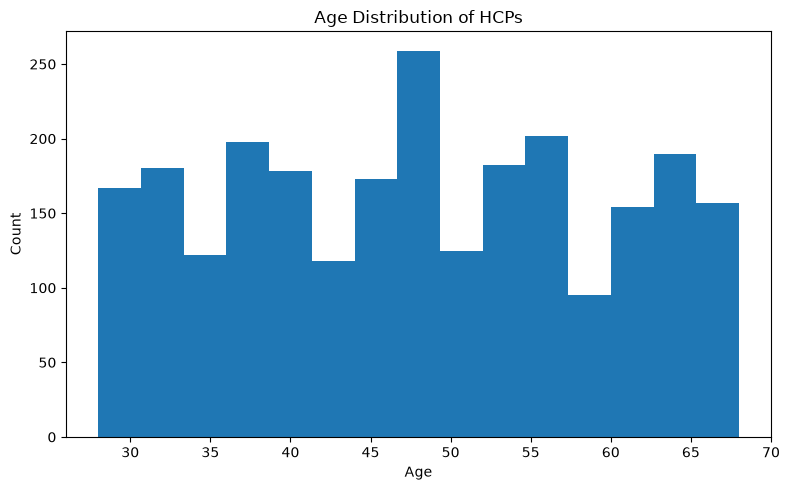

In [8]:
plt.figure(figsize=(8,5))

plt.hist(
    hcp["Age"],
    bins=15
)

plt.title("Age Distribution of HCPs")

plt.xlabel("Age")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

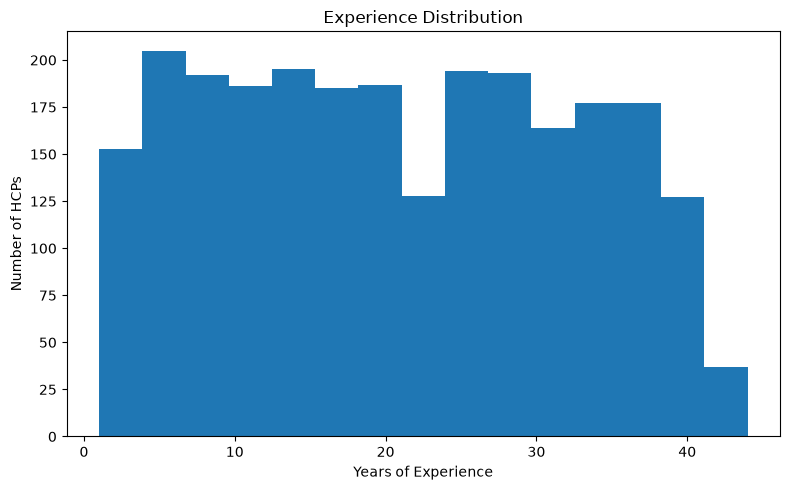

In [9]:
plt.figure(figsize=(8,5))

plt.hist(
    hcp["Experience_Years"],
    bins=15
)

plt.title("Experience Distribution")

plt.xlabel("Years of Experience")

plt.ylabel("Number of HCPs")

plt.tight_layout()

plt.show()

## Product Portfolio by Therapy Area

This chart shows the number of products available in each therapy area.

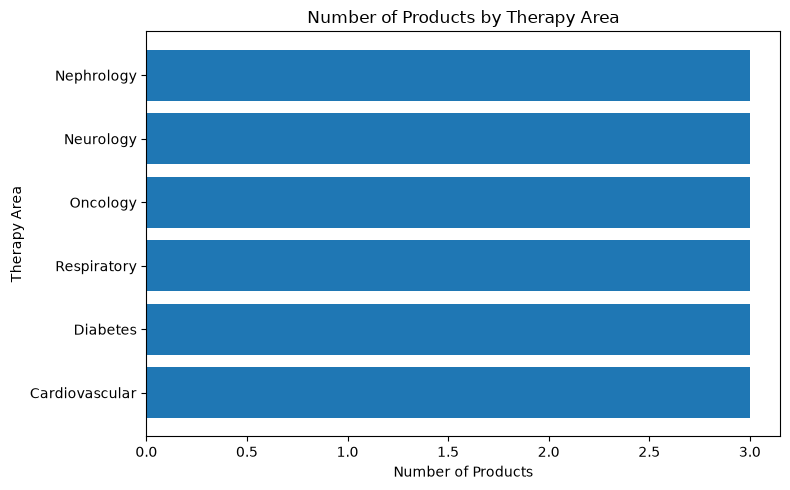

In [10]:
therapy = products["Therapy_Area"].value_counts().sort_values()

plt.figure(figsize=(8,5))

plt.barh(
    therapy.index,
    therapy.values
)

plt.title("Number of Products by Therapy Area")

plt.xlabel("Number of Products")

plt.ylabel("Therapy Area")

plt.tight_layout()

plt.show()

## Total Sales by Therapy Area

This visualization highlights the revenue generated by each therapy area.

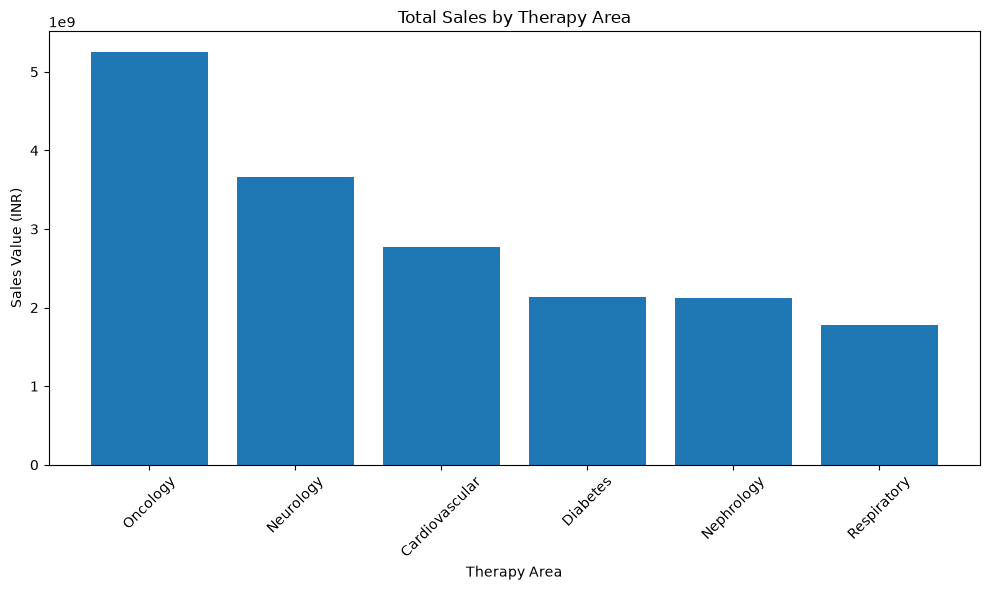

In [11]:
sales_therapy = (
    eda.groupby("Therapy_Area")["Sales_Value"]
       .sum()
       .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(
    sales_therapy.index,
    sales_therapy.values
)

plt.title("Total Sales by Therapy Area")

plt.xlabel("Therapy Area")

plt.ylabel("Sales Value (INR)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Monthly Sales Trend

This chart shows how sales vary across months.

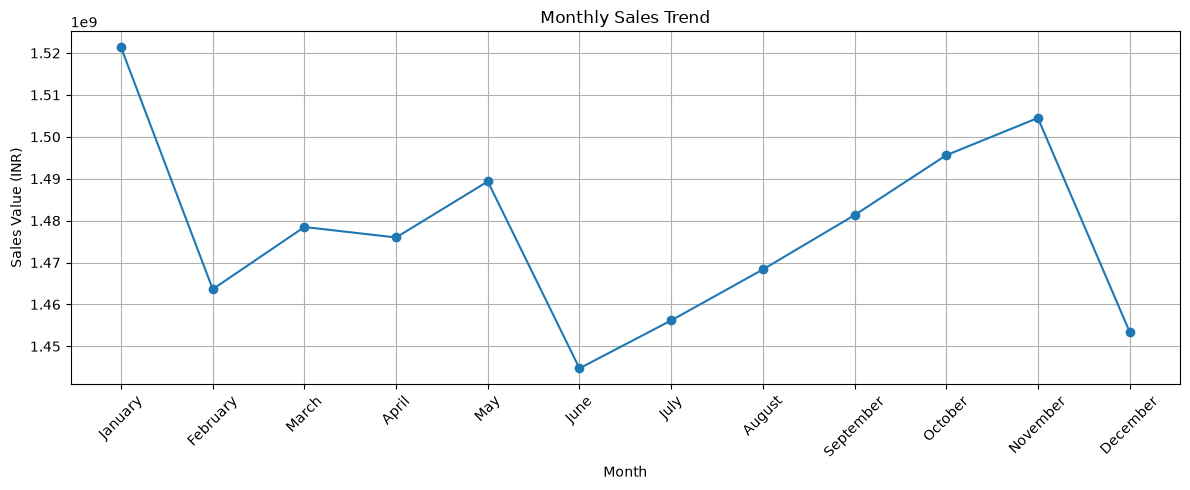

In [12]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = (
    eda.groupby("Month")["Sales_Value"]
       .sum()
       .reindex(month_order)
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales Value (INR)")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

## Monthly Total Prescriptions (TRx)

This chart displays the trend of total prescriptions over the months.

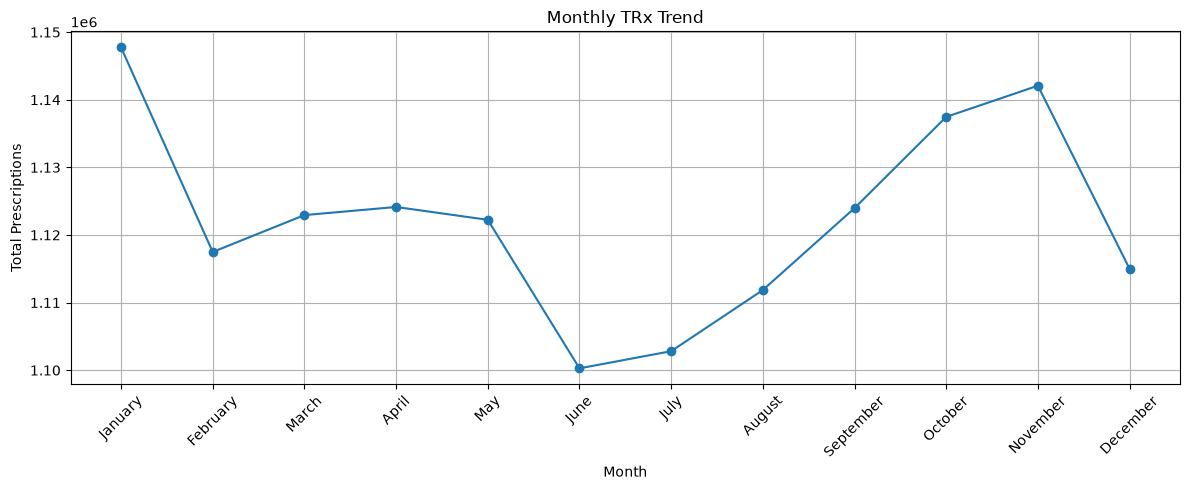

In [13]:
monthly_trx = (
    eda.groupby("Month")["TRx"]
       .sum()
       .reindex(month_order)
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_trx.index,
    monthly_trx.values,
    marker="o"
)

plt.title("Monthly TRx Trend")

plt.xlabel("Month")

plt.ylabel("Total Prescriptions")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

## Top 10 Products by Sales

This chart identifies the highest revenue-generating pharmaceutical products.

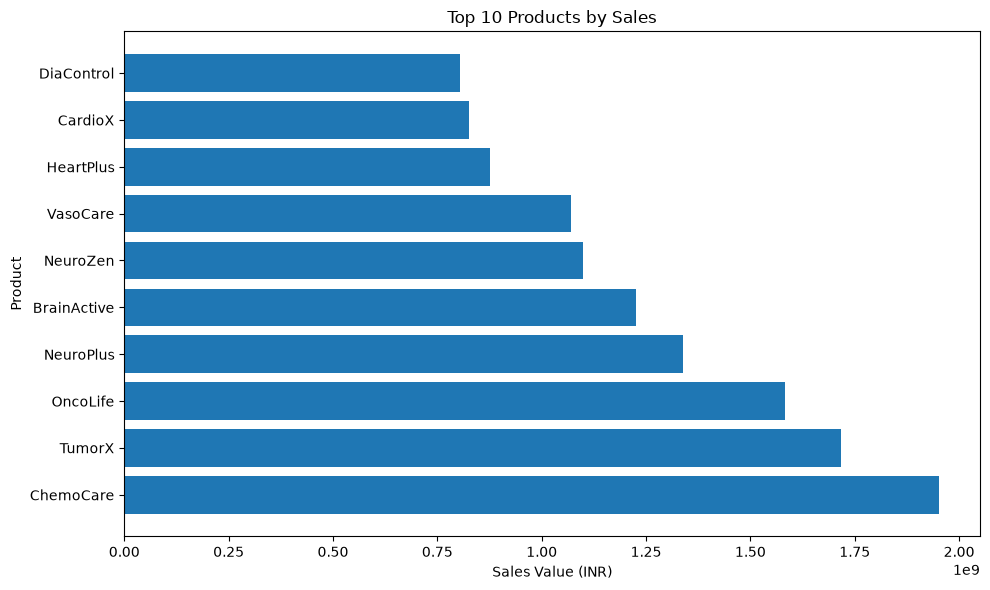

In [14]:
top_products = (
    eda.groupby("Product_Name")["Sales_Value"]
       .sum()
       .sort_values(ascending=False)
       .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 10 Products by Sales")

plt.xlabel("Sales Value (INR)")

plt.ylabel("Product")

plt.tight_layout()

plt.show()

## Top 10 HCPs by Sales

This chart highlights the healthcare professionals generating the highest sales.

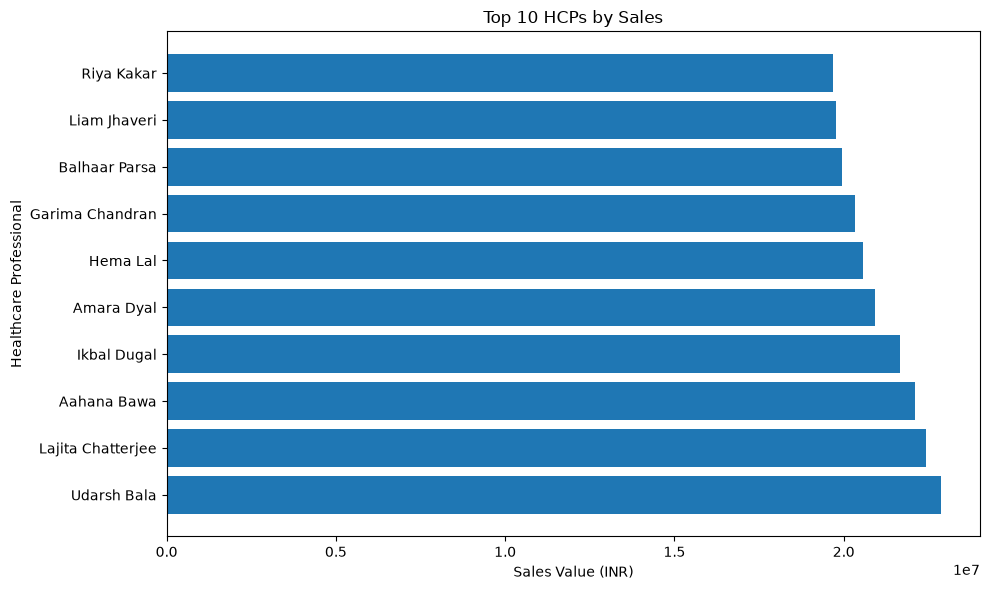

In [15]:
top_hcp = (
    eda.groupby("HCP_Name")["Sales_Value"]
       .sum()
       .sort_values(ascending=False)
       .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_hcp.index,
    top_hcp.values
)

plt.title("Top 10 HCPs by Sales")

plt.xlabel("Sales Value (INR)")

plt.ylabel("Healthcare Professional")

plt.tight_layout()

plt.show()

## Brand Awareness Distribution

This chart shows the distribution of brand awareness levels among surveyed healthcare professionals.

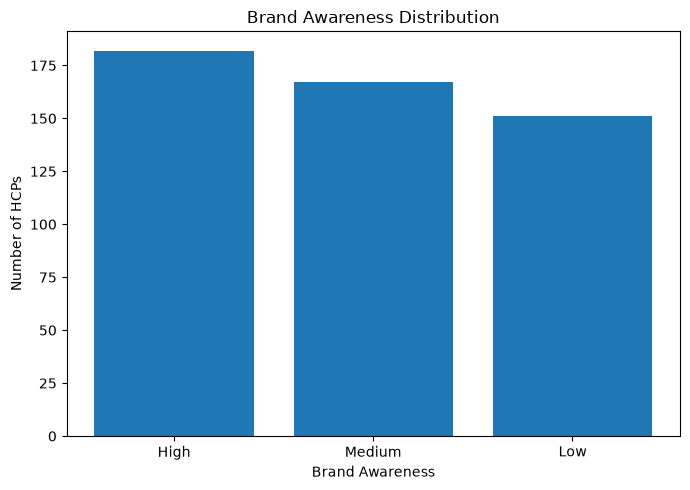

In [16]:
brand = survey["Brand_Awareness"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    brand.index,
    brand.values
)

plt.title("Brand Awareness Distribution")

plt.xlabel("Brand Awareness")

plt.ylabel("Number of HCPs")

plt.tight_layout()

plt.show()

## Adoption Mindset Distribution

This visualization shows the adoption mindset of surveyed HCPs.

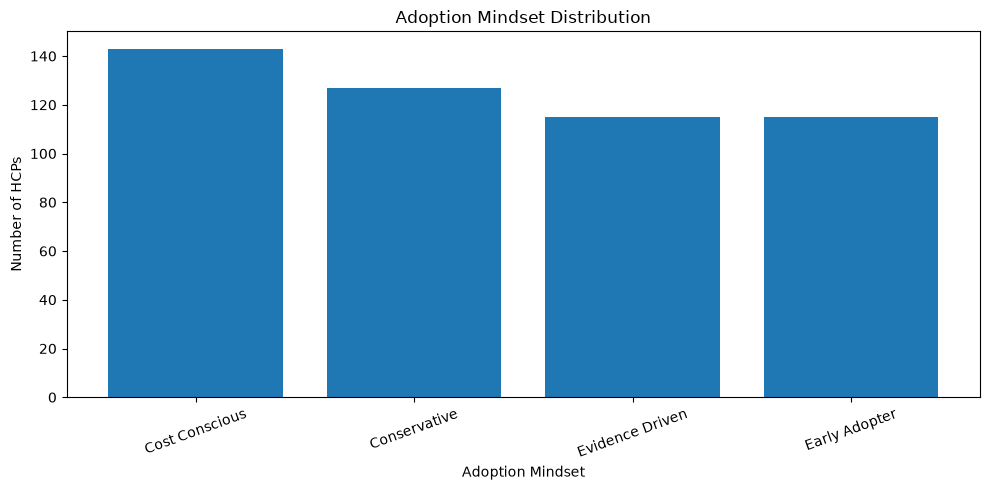

In [17]:
mindset = survey["Adoption_Mindset"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    mindset.index,
    mindset.values
)

plt.title("Adoption Mindset Distribution")

plt.xlabel("Adoption Mindset")

plt.ylabel("Number of HCPs")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Digital Engagement Distribution

This chart illustrates how digitally engaged the surveyed HCPs are.

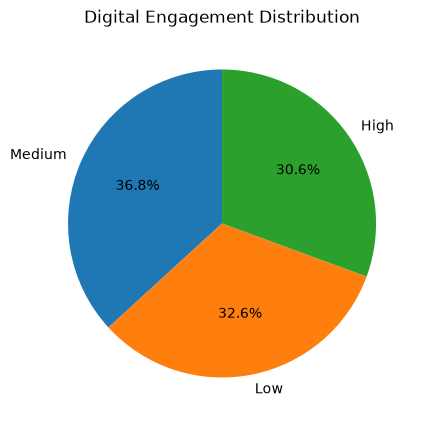

In [18]:
digital = survey["Digital_Engagement"].value_counts()

plt.figure(figsize=(7,5))

plt.pie(
    digital.values,
    labels=digital.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Digital Engagement Distribution")

plt.show()

In [23]:
numeric = eda[[
    "Age",
    "Experience_Years",
    "TRx",
    "NRx",
    "Sales_Calls",
    "Samples_Provided",
    "Sales_Value",
    "Unit_Price_INR"
]]

corr = numeric.corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    aspect="auto",
    title="Correlation Heatmap of Numeric Variables"
)
fig.write_image("../images/correlation_heatmap.png", width=1200, height=800)

fig.show()